# Image Dataset Profiling for AI-Generated Image Detection

This notebook performs data profiling on the labeled image dataset used for AI-image detection.

It is structured to answer the main questions we care about before modeling:

1. What data is actually available locally?
2. How balanced are the classes?
3. What do the images look like across classes?
4. Are there size, color, texture, or frequency-domain differences between real and AI-generated images?
5. Are there quality issues such as missing files, corrupted images, duplicates, or missing labels?

The notebook focuses on **profiling and insight generation**, not training. The goal is to surface patterns that can guide downstream feature engineering and model design.


## 1. Setup and Paths

We first import the core libraries and point the notebook at the project data directory.

Expected local layout:

- `Data/train.csv`
- `Data/test.csv`
- `Data/images_final_sample/`


In [4]:
from pathlib import Path
import hashlib
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from PIL import Image, ImageStat, UnidentifiedImageError

try:
    import cv2
except ImportError:
    cv2 = None

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'Data'
IMAGE_DIR = DATA_DIR / 'images_final_sample'
TRAIN_CSV = DATA_DIR / 'train.csv'
TEST_CSV = DATA_DIR / 'test.csv'

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

required_paths = [TRAIN_CSV, TEST_CSV, IMAGE_DIR]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError('Missing expected dataset paths: ' + ', '.join(missing_paths))

setup_df = pd.DataFrame(
    {
        'path_name': ['DATA_DIR', 'IMAGE_DIR', 'TRAIN_CSV', 'TEST_CSV'],
        'path_value': [str(DATA_DIR), str(IMAGE_DIR), str(TRAIN_CSV), str(TEST_CSV)],
    }
)
print('Setup complete. Notebook paths resolved successfully.')
display(setup_df)
DATA_DIR

Setup complete. Notebook paths resolved successfully.


,path_name,path_value
0,DATA_DIR,/Users/bitbase/workspace/github.com/rameezshaf...
1,IMAGE_DIR,/Users/bitbase/workspace/github.com/rameezshaf...
2,TRAIN_CSV,/Users/bitbase/workspace/github.com/rameezshaf...
3,TEST_CSV,/Users/bitbase/workspace/github.com/rameezshaf...


PosixPath('/Users/bitbase/workspace/github.com/rameezshafat/etsy_ai_image_detection/Data')

## 2. Load Metadata and Inspect Dataset Availability

We load the train and test metadata, attach image paths, and check which referenced files are actually available.

Class mapping used in this notebook:

- `0` = real / non-AI
- `1` = AI-generated


In [5]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

train_df['split'] = 'train'
test_df['split']  = 'test'
test_df['ground_truth'] = np.nan

metadata_df = pd.concat([train_df, test_df], ignore_index=True, sort=False)
metadata_df['image_path'] = metadata_df['image_id'].map(lambda name: IMAGE_DIR / name)
metadata_df['file_exists'] = metadata_df['image_path'].map(Path.exists)
metadata_df['label_name']  = metadata_df['ground_truth'].map({0: 'real', 1: 'ai_generated'})
metadata_df['label_name']  = metadata_df['label_name'].fillna('unlabeled_test')

total_images     = len(metadata_df)
available_images = int(metadata_df['file_exists'].sum())
missing_images   = total_images - available_images

print('─' * 50)
print('DATASET LOADING SUMMARY')
print('─' * 50)
print(f'  Total images referenced : {total_images:,}')
print(f'  Available on disk       : {available_images:,}  ({100*available_images/total_images:.1f}%)')
print(f'  Missing files           : {missing_images:,}')
print(f'  Train rows              : {len(train_df):,}')
print(f'  Test rows               : {len(test_df):,}')
print('─' * 50)
display(metadata_df.head())


──────────────────────────────────────────────────
DATASET LOADING SUMMARY
──────────────────────────────────────────────────
  Total images referenced : 6,858
  Available on disk       : 6,858  (100.0%)
  Missing files           : 0
  Train rows              : 4,800
  Test rows               : 2,058
──────────────────────────────────────────────────


,image_id,ground_truth,split,image_path,file_exists,label_name
0,e7ea0752-f24a-4dac-926c-371fda631a0f.jpg,1.0,train,/Users/bitbase/workspace/github.com/rameezshaf...,True,ai_generated
1,cdc7b8e5-1609-4f88-a20d-0dd321f8f489.jpg,0.0,train,/Users/bitbase/workspace/github.com/rameezshaf...,True,real
2,c954e18f-8ab3-4bff-91d7-a0d7ff000e51.jpg,0.0,train,/Users/bitbase/workspace/github.com/rameezshaf...,True,real
3,1c5fb5d5-75e0-431f-a03e-e50026f23fe3.jpg,0.0,train,/Users/bitbase/workspace/github.com/rameezshaf...,True,real
4,fd0dd104-7300-4da3-a46f-6980531ead33.jpg,1.0,train,/Users/bitbase/workspace/github.com/rameezshaf...,True,ai_generated


In [6]:
overview = pd.DataFrame({
    'rows':            metadata_df.groupby('split').size(),
    'available_files': metadata_df.groupby('split')['file_exists'].sum(),
    'missing_files':   metadata_df.groupby('split').size() - metadata_df.groupby('split')['file_exists'].sum(),
})
overview['availability_pct'] = (overview['available_files'] / overview['rows'] * 100).round(1)
print('Dataset availability overview:')
display(overview)


Dataset availability overview:


,rows,available_files,missing_files,availability_pct
split,,,,
test,2058,2058,0,100.0
train,4800,4800,0,100.0


In [7]:
train_class_distribution = (
    metadata_df.loc[metadata_df['split'] == 'train', 'ground_truth']
    .value_counts(dropna=False)
    .sort_index()
    .rename(index={0.0: 'real', 1.0: 'ai_generated'})
    .to_frame('count')
)
train_class_distribution['share'] = train_class_distribution['count'] / train_class_distribution['count'].sum()
print('Training class distribution:')
display(train_class_distribution)

real_count = int(train_class_distribution.loc['real', 'count']) if 'real' in train_class_distribution.index else 0
ai_count   = int(train_class_distribution.loc['ai_generated', 'count']) if 'ai_generated' in train_class_distribution.index else 0
balance    = min(real_count, ai_count) / max(real_count, ai_count) if max(real_count, ai_count) > 0 else 0
print(f'\nTotal training images : {real_count + ai_count:,}')
print(f'  Real         : {real_count:,}')
print(f'  AI-generated : {ai_count:,}')
print(f'Balance ratio (minority / majority): {balance:.3f}  {"[balanced]" if balance > 0.8 else "[imbalanced — consider resampling]"}')


Training class distribution:


,count,share
ground_truth,,
real,2485,0.517708
ai_generated,2315,0.482292



Total training images : 4,800
  Real         : 2,485
  AI-generated : 2,315
Balance ratio (minority / majority): 0.932  [balanced]


## 3. Dataset Size and Class Distribution

This gives us the high-level balance of the labeled training data and the amount of image coverage we have locally.


/var/folders/b9/6zpjb9xx1qd6qrrkz6nmb64w0000gn/T/ipykernel_29855/936004971.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


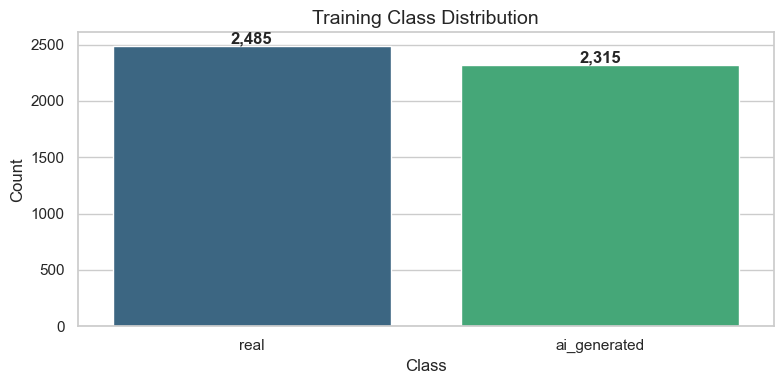

In [8]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=metadata_df.loc[metadata_df['split'] == 'train'],
    x='label_name',
    order=['real', 'ai_generated'],
    palette='viridis',
)
ax.set_title('Training Class Distribution', fontsize=14)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height()):,}',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=12, fontweight='bold',
    )
plt.tight_layout()
plt.show()


## 4. Display Sample Images

Before statistics, it is always worth visually checking what each class actually looks like.


Showing 4 real and 4 AI-generated sample images.
Row 1: Real images  |  Row 2: AI-generated images


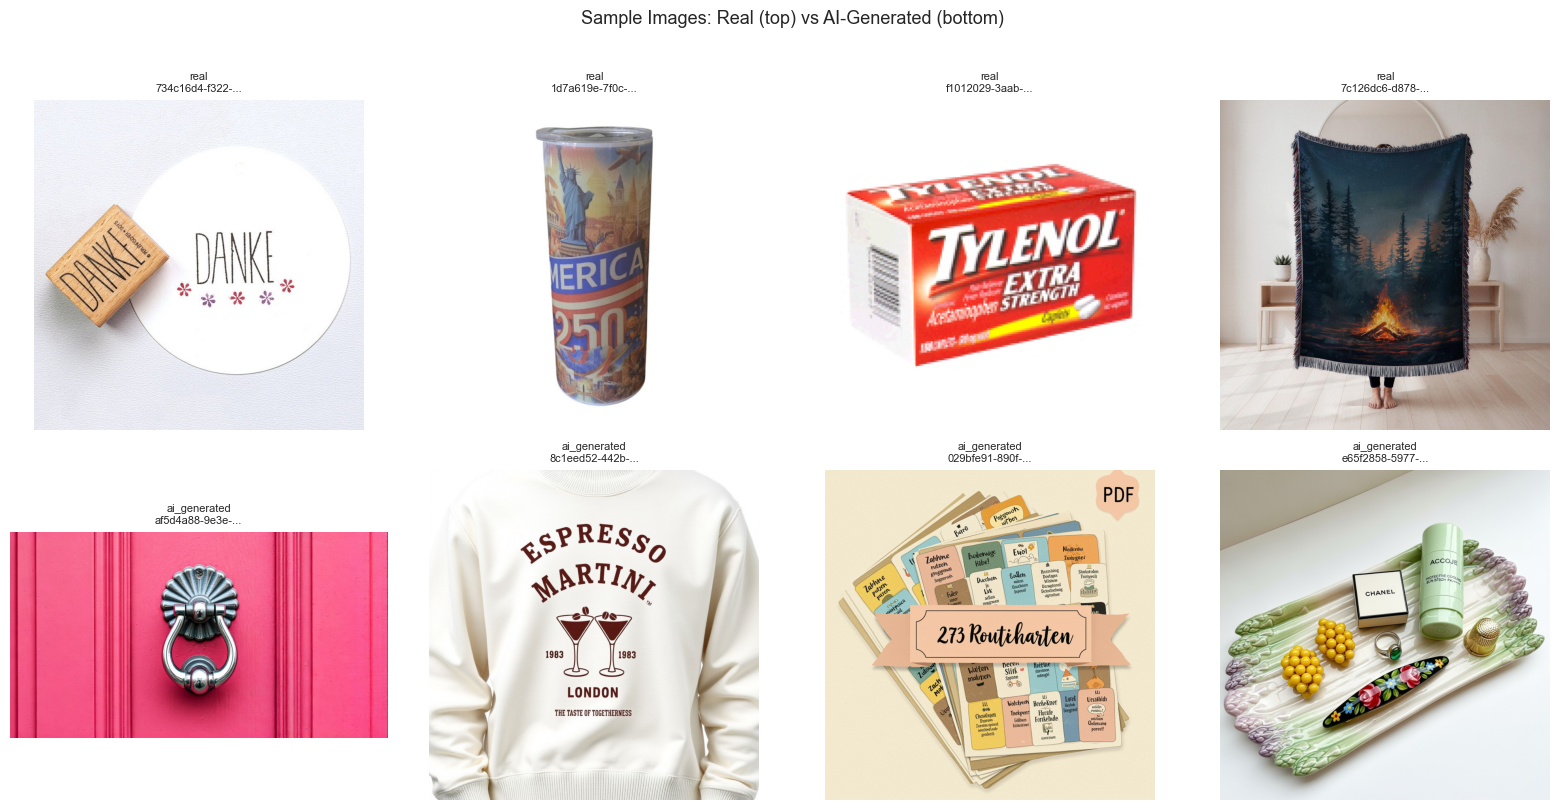

In [9]:
rng = np.random.default_rng(42)
available_train = metadata_df[(metadata_df['split'] == 'train') & (metadata_df['file_exists'])].copy()

sample_real = available_train.loc[available_train['ground_truth'] == 0].sample(4, random_state=42)
sample_ai   = available_train.loc[available_train['ground_truth'] == 1].sample(4, random_state=42)
sample_rows = pd.concat([sample_real, sample_ai], ignore_index=True)

print(f'Showing {len(sample_real)} real and {len(sample_ai)} AI-generated sample images.')
print('Row 1: Real images  |  Row 2: AI-generated images')
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flatten(), sample_rows.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(row['label_name'] + '\n' + row['image_id'][:14] + '...', fontsize=8)
    ax.axis('off')
fig.suptitle('Sample Images: Real (top) vs AI-Generated (bottom)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 5. Profiling Helper Functions

The next cell defines a small profiling pipeline that extracts:

- image size and aspect ratio
- file size
- RGB mean and standard deviation
- intensity histograms
- smoothness / texture proxies
- FFT-based high-frequency energy ratio
- EXIF metadata counts
- corruption flags
- duplicate hashes

These are useful both for dataset auditing and for surfacing candidate AI-vs-real signals.


In [10]:
def compute_md5(path: Path, chunk_size: int = 8192) -> str:
    hash_md5 = hashlib.md5()
    with path.open('rb') as f:
        for chunk in iter(lambda: f.read(chunk_size), b''):
            hash_md5.update(chunk)
    return hash_md5.hexdigest()


def image_profile(path: Path) -> dict:
    record = {
        'image_path': path,
        'file_name': path.name,
        'file_size_bytes': np.nan,
        'width': np.nan,
        'height': np.nan,
        'aspect_ratio': np.nan,
        'rgb_mean_r': np.nan,
        'rgb_mean_g': np.nan,
        'rgb_mean_b': np.nan,
        'rgb_std_r': np.nan,
        'rgb_std_g': np.nan,
        'rgb_std_b': np.nan,
        'pixel_mean': np.nan,
        'pixel_std': np.nan,
        'laplacian_var': np.nan,
        'fft_high_freq_ratio': np.nan,
        'exif_tag_count': 0,
        'has_exif': False,
        'is_corrupted': False,
        'md5': None,
    }

    try:
        record['file_size_bytes'] = path.stat().st_size
        record['md5'] = compute_md5(path)

        with Image.open(path) as img:
            exif = img.getexif()
            record['exif_tag_count'] = len(exif) if exif is not None else 0
            record['has_exif'] = record['exif_tag_count'] > 0

            img = img.convert('RGB')
            arr = np.asarray(img, dtype=np.float32)

            h, w, _ = arr.shape
            record['width'] = w
            record['height'] = h
            record['aspect_ratio'] = w / h if h else np.nan

            rgb_means = arr.mean(axis=(0, 1))
            rgb_stds = arr.std(axis=(0, 1))
            record['rgb_mean_r'], record['rgb_mean_g'], record['rgb_mean_b'] = rgb_means
            record['rgb_std_r'], record['rgb_std_g'], record['rgb_std_b'] = rgb_stds

            gray = arr.mean(axis=2)
            record['pixel_mean'] = gray.mean()
            record['pixel_std'] = gray.std()

            if cv2 is not None:
                record['laplacian_var'] = cv2.Laplacian(gray.astype(np.float32), cv2.CV_32F).var()

            fft = np.fft.fftshift(np.fft.fft2(gray))
            magnitude = np.abs(fft)
            cy, cx = magnitude.shape[0] // 2, magnitude.shape[1] // 2
            radius = max(4, min(magnitude.shape) // 8)
            yy, xx = np.ogrid[:magnitude.shape[0], :magnitude.shape[1]]
            distance = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
            high_freq_energy = magnitude[distance >= radius].sum()
            total_energy = magnitude.sum()
            record['fft_high_freq_ratio'] = float(high_freq_energy / total_energy) if total_energy else np.nan

    except (UnidentifiedImageError, OSError, ValueError):
        record['is_corrupted'] = True

    return record


def intensity_histogram(path: Path, bins: int = 32) -> np.ndarray:
    with Image.open(path) as img:
        img = img.convert('L')
        arr = np.asarray(img, dtype=np.uint8)
    hist, _ = np.histogram(arr, bins=bins, range=(0, 255), density=True)
    return hist

helper_df = pd.DataFrame(
    {
        'helper_name': ['compute_md5', 'image_profile', 'intensity_histogram'],
        'purpose': [
            'content hashing for duplicate detection',
            'structural + pixel + metadata profiling',
            'grayscale intensity distribution extraction',
        ],
    }
)
print('Profiling helper functions are ready.')
display(helper_df)

Profiling helper functions are ready.


,helper_name,purpose
0,compute_md5,content hashing for duplicate detection
1,image_profile,structural + pixel + metadata profiling
2,intensity_histogram,grayscale intensity distribution extraction


## 6. Run Dataset Profiling

This cell iterates over all locally available images referenced by the metadata and builds a profiling table.

Depending on disk speed and image count, this may take a little time.


In [11]:
available_metadata = metadata_df.loc[metadata_df['file_exists']].copy().reset_index(drop=True)
print(f'Profiling {len(available_metadata):,} images — this may take a moment...')
profile_records = [image_profile(path) for path in available_metadata['image_path']]
profile_df = pd.DataFrame(profile_records)
profile_df = available_metadata.merge(profile_df, on='image_path', how='left')
profile_df['file_size_kb'] = profile_df['file_size_bytes'] / 1024
profile_df['is_duplicate'] = profile_df['md5'].duplicated(keep=False)

n_total     = len(profile_df)
n_corrupted = int(profile_df['is_corrupted'].sum())
n_duplicates= int(profile_df['is_duplicate'].sum())
n_with_exif = int(profile_df['has_exif'].sum())

print('\n' + '─' * 50)
print('PROFILING COMPLETE')
print('─' * 50)
print(f'  Total profiles    : {n_total:,}')
print(f'  Corrupted images  : {n_corrupted:,}  ({100*n_corrupted/n_total:.1f}%)')
print(f'  Duplicate images  : {n_duplicates:,}  ({100*n_duplicates/n_total:.1f}%)')
print(f'  Images with EXIF  : {n_with_exif:,}  ({100*n_with_exif/n_total:.1f}%)')
print('─' * 50)
display(profile_df[['image_id', 'label_name', 'split', 'width', 'height',
                     'file_size_kb', 'is_corrupted', 'is_duplicate']].head(10))


Profiling 6,858 images — this may take a moment...

──────────────────────────────────────────────────
PROFILING COMPLETE
──────────────────────────────────────────────────
  Total profiles    : 6,858
  Corrupted images  : 0  (0.0%)
  Duplicate images  : 0  (0.0%)
  Images with EXIF  : 614  (9.0%)
──────────────────────────────────────────────────


,image_id,label_name,split,width,height,file_size_kb,is_corrupted,is_duplicate
0,e7ea0752-f24a-4dac-926c-371fda631a0f.jpg,ai_generated,train,1024,1024,350.721680,False,False
1,cdc7b8e5-1609-4f88-a20d-0dd321f8f489.jpg,real,train,2404,2404,876.510742,False,False
2,c954e18f-8ab3-4bff-91d7-a0d7ff000e51.jpg,real,train,1195,896,197.401367,False,False
3,1c5fb5d5-75e0-431f-a03e-e50026f23fe3.jpg,real,train,1024,1024,149.186523,False,False
4,fd0dd104-7300-4da3-a46f-6980531ead33.jpg,ai_generated,train,1024,716,168.994141,False,False
5,c83a1e71-ffe7-46a1-9ec5-b235357c3e39.jpg,real,train,1280,1024,199.155273,False,False
6,56b718b3-2f41-4331-a8d8-13fa11439752.jpg,real,train,1195,896,178.536133,False,False
7,a5f86ae3-b2f3-4026-b5e4-bb918d902c9a.jpg,ai_generated,train,1024,1024,91.932617,False,False
8,826958f4-16f0-42e1-8adf-d25a0c8e900a.jpg,real,train,1248,832,249.530273,False,False
9,5c754abd-97cd-446e-a8a6-612f94657b37.jpg,ai_generated,train,896,1195,367.584961,False,False


## 7. Basic Image Statistics

We summarize the main structural properties of the images:

- width
-  height
- aspect ratio
- file size

These often expose quirks in data collection or generation pipelines.


In [12]:
basic_stats = profile_df[['width', 'height', 'aspect_ratio', 'file_size_kb']].describe().T
basic_stats['median'] = profile_df[['width', 'height', 'aspect_ratio', 'file_size_kb']].median()
print('Basic image statistics (all splits):')
display(basic_stats[['mean', 'median', 'min', 'max', 'std']].round(2))

w_unique = profile_df['width'].nunique()
h_unique = profile_df['height'].nunique()
print(f'\nKey observations:')
print(f'  Unique widths   : {w_unique}  |  Unique heights : {h_unique}')
print(f'  Resolution range: {int(profile_df["width"].min())}x{int(profile_df["height"].min())} → '
      f'{int(profile_df["width"].max())}x{int(profile_df["height"].max())}')
print(f'  File size range : {profile_df["file_size_kb"].min():.1f} KB → {profile_df["file_size_kb"].max():.1f} KB')


Basic image statistics (all splits):


,mean,median,min,max,std
width,1013.35,1024.00,36.00,3024.00,244.63
height,1005.79,1024.00,54.00,4032.00,274.30
aspect_ratio,1.06,1.00,0.23,9.52,0.33
file_size_kb,198.20,179.59,4.35,3424.59,135.85



Key observations:
  Unique widths   : 153  |  Unique heights : 186
  Resolution range: 36x54 → 3024x4032
  File size range : 4.3 KB → 3424.6 KB


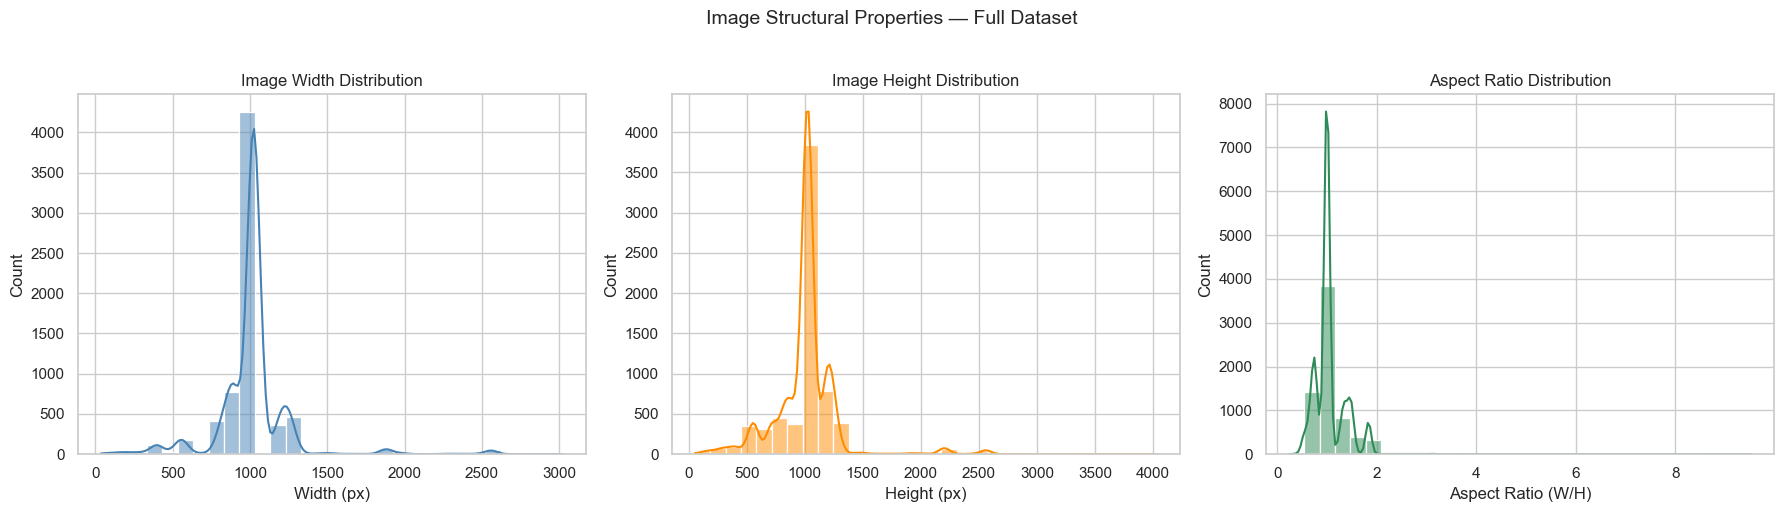

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(profile_df['width'], bins=30, ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Image Width Distribution', fontsize=12)
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
sns.histplot(profile_df['height'], bins=30, ax=axes[1], kde=True, color='darkorange')
axes[1].set_title('Image Height Distribution', fontsize=12)
axes[1].set_xlabel('Height (px)')
axes[1].set_ylabel('Count')
sns.histplot(profile_df['aspect_ratio'], bins=30, ax=axes[2], kde=True, color='seagreen')
axes[2].set_title('Aspect Ratio Distribution', fontsize=12)
axes[2].set_xlabel('Aspect Ratio (W/H)')
axes[2].set_ylabel('Count')
fig.suptitle('Image Structural Properties — Full Dataset', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 8. Class-Wise Image Size and File Size Comparisons

If AI-generated and real images come from different pipelines, they may differ in size, compression, or aspect-ratio habits.


Class-wise file size and aspect ratio summary:


file_size_kb                 aspect_ratio             
                     mean  median     std         mean median   std
label_name                                                         
ai_generated       186.02  170.43   89.09         1.09    1.0  0.32
real               208.88  188.85  163.69         1.02    1.0  0.31


Mean file size — Real: 208.9 KB  |  AI-generated: 186.0 KB  |  Δ: 22.9 KB


/var/folders/b9/6zpjb9xx1qd6qrrkz6nmb64w0000gn/T/ipykernel_29855/2544558650.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled_profile_df, x='label_name', y='file_size_kb', ax=axes[0], palette='Set2')
/var/folders/b9/6zpjb9xx1qd6qrrkz6nmb64w0000gn/T/ipykernel_29855/2544558650.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labeled_profile_df, x='label_name', y='aspect_ratio', ax=axes[1], palette='Set3')


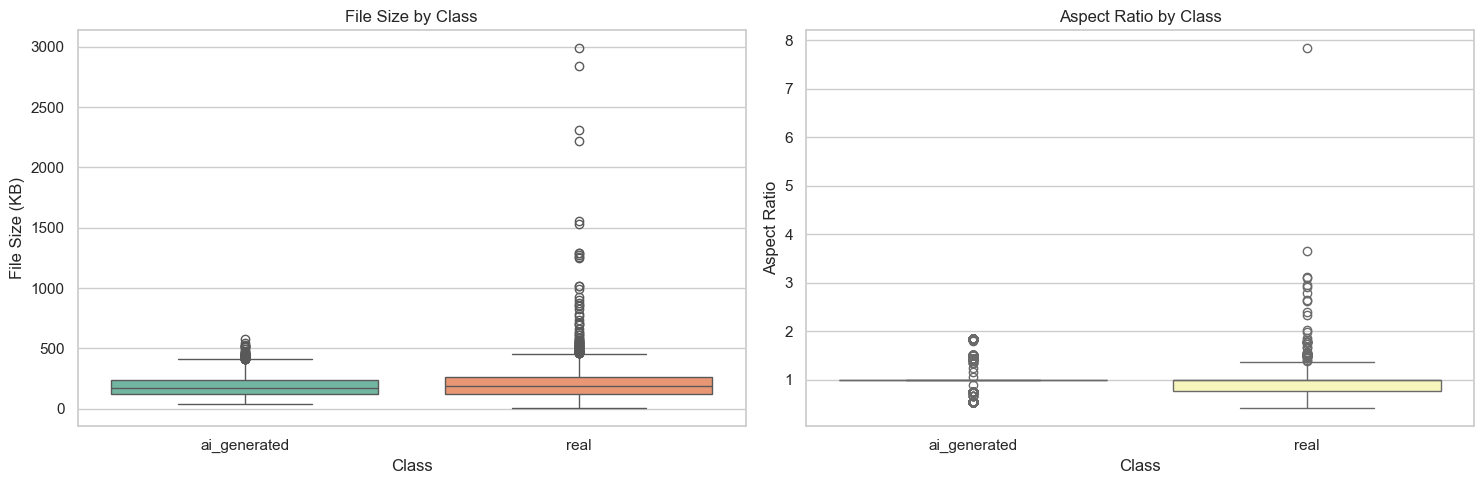

In [14]:
labeled_profile_df = profile_df.loc[profile_df['split'] == 'train'].copy()
class_size_summary = (
    labeled_profile_df.groupby('label_name')[['file_size_kb', 'aspect_ratio']]
    .agg(['mean', 'median', 'std'])
)
print('Class-wise file size and aspect ratio summary:')
display(class_size_summary.round(2))

classes = labeled_profile_df['label_name'].unique()
if 'real' in classes and 'ai_generated' in classes:
    real_sz = labeled_profile_df.loc[labeled_profile_df['label_name']=='real', 'file_size_kb'].mean()
    ai_sz   = labeled_profile_df.loc[labeled_profile_df['label_name']=='ai_generated', 'file_size_kb'].mean()
    print(f'\nMean file size — Real: {real_sz:.1f} KB  |  AI-generated: {ai_sz:.1f} KB  |  \u0394: {abs(real_sz-ai_sz):.1f} KB')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=labeled_profile_df, x='label_name', y='file_size_kb',
            ax=axes[0], hue='label_name', palette='Set2', legend=False)
axes[0].set_title('File Size by Class', fontsize=12)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('File Size (KB)')
sns.boxplot(data=labeled_profile_df, x='label_name', y='aspect_ratio',
            ax=axes[1], hue='label_name', palette='Set3', legend=False)
axes[1].set_title('Aspect Ratio by Class', fontsize=12)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Aspect Ratio')
plt.tight_layout()
plt.show()


## 9. Pixel-Level RGB Statistics

We compare RGB means and standard deviations by class. These are simple statistics, but they can highlight color-distribution differences between AI-generated and real images.


In [15]:
rgb_summary = (
    labeled_profile_df.groupby('label_name')[
        ['rgb_mean_r', 'rgb_mean_g', 'rgb_mean_b',
         'rgb_std_r',  'rgb_std_g',  'rgb_std_b',
         'pixel_mean', 'pixel_std']
    ]
    .agg(['mean', 'median'])
)
print('RGB and grayscale channel summary by class:')
display(rgb_summary.round(2))

classes = labeled_profile_df['label_name'].unique()
if 'real' in classes and 'ai_generated' in classes:
    print('\nPer-channel mean differences (Real − AI-generated):')
    for col, label in [('rgb_mean_r','R'), ('rgb_mean_g','G'), ('rgb_mean_b','B')]:
        r = labeled_profile_df.loc[labeled_profile_df['label_name']=='real',        col].mean()
        a = labeled_profile_df.loc[labeled_profile_df['label_name']=='ai_generated', col].mean()
        print(f'  Channel {label}: Real={r:.2f}  AI={a:.2f}  Δ={r-a:+.2f}')


RGB and grayscale channel summary by class:


rgb_mean_r              rgb_mean_g              rgb_mean_b  \
                    mean      median        mean      median        mean   
label_name                                                                 
ai_generated  165.789993  164.979996  155.649994  155.289993  145.589996   
real          170.039993  174.039993  159.649994  163.009995  151.539993   

                         rgb_std_r             rgb_std_g             \
                  median      mean     median       mean     median   
label_name                                                            
ai_generated  146.089996     54.77  54.080002  56.230000  56.730000   
real          154.779999     56.07  55.919998  57.509998  57.369999   

              rgb_std_b             pixel_mean              pixel_std  \
                   mean     median        mean      median       mean   
label_name                                                              
ai_generated  59.220001  59.450001  155.619995  155.339996  55.130001   
real          60.110001  59.520000  160.289993  163.179993  55.880001   

                         
                 median  
label_name               
ai_generated  55.160000  
real          55.790001


Per-channel mean differences (Real − AI-generated):
  Channel R: Real=170.04  AI=165.79  Δ=+4.25
  Channel G: Real=159.65  AI=155.65  Δ=+4.00
  Channel B: Real=151.54  AI=145.59  Δ=+5.95


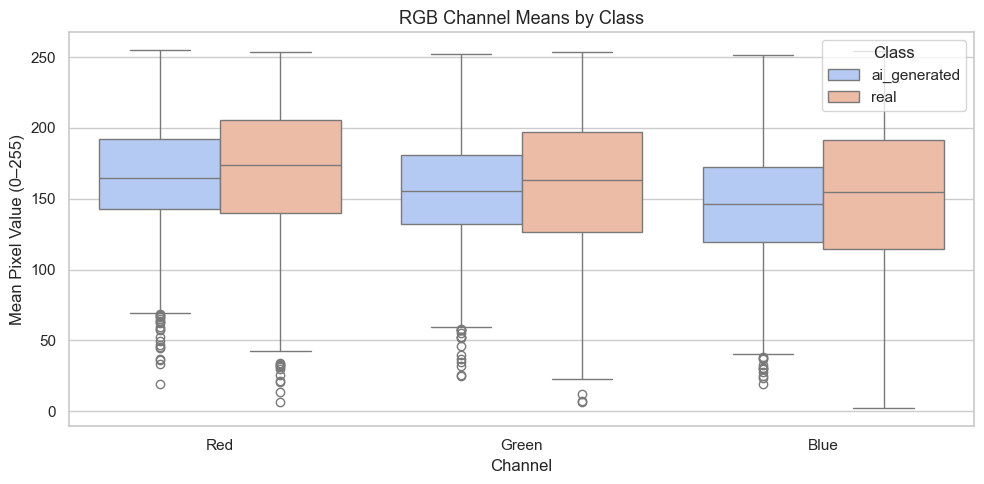

In [16]:
rgb_means_long = labeled_profile_df.melt(
    id_vars=['label_name'],
    value_vars=['rgb_mean_r', 'rgb_mean_g', 'rgb_mean_b'],
    var_name='channel',
    value_name='value',
)
rgb_means_long['channel'] = rgb_means_long['channel'].map(
    {'rgb_mean_r': 'Red', 'rgb_mean_g': 'Green', 'rgb_mean_b': 'Blue'}
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=rgb_means_long, x='channel', y='value', hue='label_name', palette='coolwarm')
plt.title('RGB Channel Means by Class', fontsize=13)
plt.xlabel('Channel')
plt.ylabel('Mean Pixel Value (0–255)')
plt.legend(title='Class')
plt.tight_layout()
plt.show()


## 10. Pixel Intensity Histograms

We compute average grayscale intensity histograms on a balanced sample of real and AI-generated images to compare tone distributions.


Pixel histogram comparison — 200 real vs 200 AI-generated images.
Peak density intensity — Real: ~255  |  AI-generated: ~222
Max absolute histogram difference: 0.00770


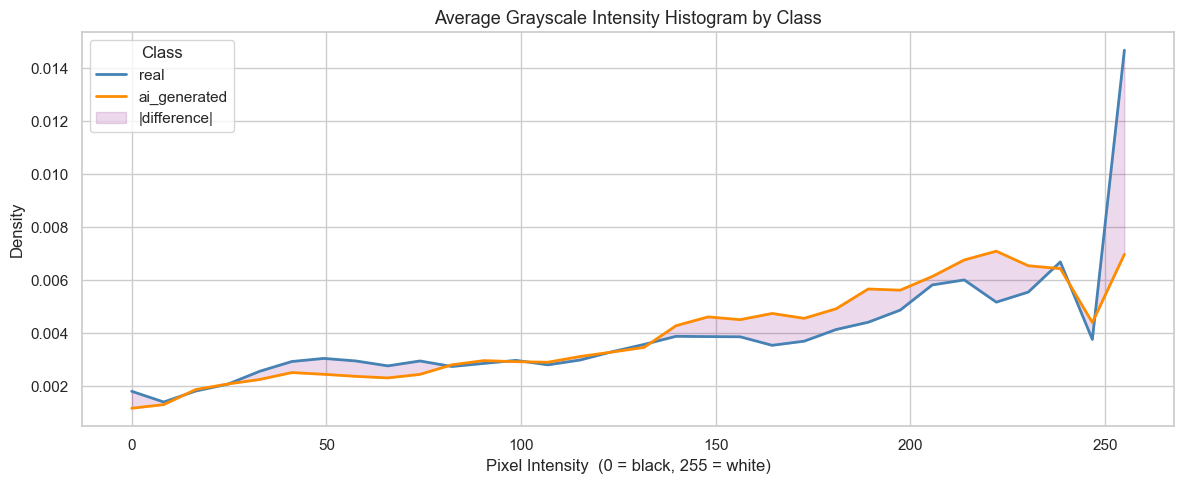

In [17]:
hist_sample_size = min(200, labeled_profile_df['ground_truth'].value_counts().min())
real_sample_paths = labeled_profile_df.loc[labeled_profile_df['ground_truth'] == 0, 'image_path'].sample(hist_sample_size, random_state=42)
ai_sample_paths   = labeled_profile_df.loc[labeled_profile_df['ground_truth'] == 1, 'image_path'].sample(hist_sample_size, random_state=42)

real_hist = np.mean([intensity_histogram(p) for p in real_sample_paths], axis=0)
ai_hist   = np.mean([intensity_histogram(p) for p in ai_sample_paths],   axis=0)

bin_centers    = np.linspace(0, 255, len(real_hist))
real_peak_bin  = bin_centers[np.argmax(real_hist)]
ai_peak_bin    = bin_centers[np.argmax(ai_hist)]
max_abs_diff   = float(np.max(np.abs(real_hist - ai_hist)))

print(f'Pixel histogram comparison — {hist_sample_size} real vs {hist_sample_size} AI-generated images.')
print(f'Peak density intensity — Real: ~{real_peak_bin:.0f}  |  AI-generated: ~{ai_peak_bin:.0f}')
print(f'Max absolute histogram difference: {max_abs_diff:.5f}')

plt.figure(figsize=(12, 5))
plt.plot(bin_centers, real_hist, label='real',         linewidth=2, color='steelblue')
plt.plot(bin_centers, ai_hist,   label='ai_generated', linewidth=2, color='darkorange')
plt.fill_between(bin_centers, real_hist, ai_hist, alpha=0.15, color='purple', label='|difference|')
plt.title('Average Grayscale Intensity Histogram by Class', fontsize=13)
plt.xlabel('Pixel Intensity  (0 = black, 255 = white)')
plt.ylabel('Density')
plt.legend(title='Class')
plt.tight_layout()
plt.show()


## 11. Texture, Smoothness, and Noise Proxies

We use simple proxies for texture and noise:

- `laplacian_var`: higher values usually mean more edges / texture detail
- `pixel_std`: broader overall intensity spread
- `fft_high_freq_ratio`: a rough frequency-domain proxy for high-frequency content

These are not perfect, but they are useful first-pass indicators for detecting overly smooth or artifact-heavy images.


In [18]:
texture_summary = (
    labeled_profile_df.groupby('label_name')[['laplacian_var', 'pixel_std', 'fft_high_freq_ratio']]
    .agg(['mean', 'median', 'std'])
)
print('Texture, smoothness, and frequency summary by class:')
display(texture_summary.round(4))

classes = labeled_profile_df['label_name'].unique()
if 'real' in classes and 'ai_generated' in classes:
    print('\nKey differences:')
    for col, name in [('laplacian_var','Edge/Texture (Laplacian var)'),
                      ('pixel_std',    'Pixel std dev'),
                      ('fft_high_freq_ratio','FFT high-freq ratio')]:
        r = labeled_profile_df.loc[labeled_profile_df['label_name']=='real',        col].mean()
        a = labeled_profile_df.loc[labeled_profile_df['label_name']=='ai_generated', col].mean()
        higher = 'Real higher' if r > a else 'AI higher'
        print(f'  {name:35s}: Real={r:.4f}  AI={a:.4f}  [{higher}]')


Texture, smoothness, and frequency summary by class:


laplacian_var             pixel_std                      \
                      mean median std       mean     median      std   
label_name                                                             
ai_generated           NaN    NaN NaN  55.129299  55.160999  15.6727   
real                   NaN    NaN NaN  55.880001  55.793301  17.8419   

             fft_high_freq_ratio                  
                            mean  median     std  
label_name                                        
ai_generated              0.6409  0.6471  0.0911  
real                      0.6328  0.6367  0.0981


Key differences:
  Edge/Texture (Laplacian var)       : Real=nan  AI=nan  [AI higher]
  Pixel std dev                      : Real=55.8800  AI=55.1293  [Real higher]
  FFT high-freq ratio                : Real=0.6328  AI=0.6409  [AI higher]


In [ ]:
scatter_df = labeled_profile_df.sample(min(len(labeled_profile_df), 1000), random_state=42)
corr = scatter_df[['laplacian_var', 'fft_high_freq_ratio']].corr().iloc[0, 1]
print(f'Pearson correlation — Laplacian Var vs FFT High-Freq Ratio: {corr:.4f}')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=scatter_df,
    x='laplacian_var',
    y='fft_high_freq_ratio',
    hue='label_name',
    alpha=0.6,
    palette='Set1',
)
plt.title('Texture vs Frequency: Real vs AI-Generated', fontsize=13)
plt.xlabel('Laplacian Variance (edge/texture strength)')
plt.ylabel('FFT High-Frequency Ratio')
plt.legend(title='Class')
plt.tight_layout()
plt.show()


## 12. Metadata and EXIF Analysis

EXIF is often sparse in generated-image datasets, but when available it can be very informative. Real camera images may retain metadata, while synthetic images often have no EXIF or stripped metadata.


In [21]:
metadata_summary = (
    profile_df.groupby(['split', 'label_name'])[['has_exif', 'exif_tag_count']]
    .agg(['mean', 'sum', 'median'])
)
print('Metadata / EXIF summary:')
display(metadata_summary.round(4))

exif_by_class = labeled_profile_df.groupby('label_name')['has_exif'].mean().sort_values(ascending=False)
print('\nShare of images with EXIF metadata by class:')
display(exif_by_class.to_frame('share_with_exif').round(4))

print('\nNotable pattern:')
print('  Real camera images typically carry EXIF (GPS, camera model, timestamp, etc.).')
print('  AI-generated images usually lack EXIF — this can be a strong detection signal.')
classes = exif_by_class.index.tolist()
if 'real' in classes and 'ai_generated' in classes:
    print(f'  Real with EXIF         : {exif_by_class["real"]:.1%}')
    print(f'  AI-generated with EXIF : {exif_by_class["ai_generated"]:.1%}')
    gap = exif_by_class['real'] - exif_by_class['ai_generated']
    print(f'  Gap                    : {gap:+.1%}')


Metadata / EXIF summary:


has_exif             exif_tag_count            
                         mean  sum median           mean  sum median
split label_name                                                    
test  unlabeled_test   0.0938  193    0.0         0.1876  386    0.0
train ai_generated     0.0924  214    0.0         0.1849  428    0.0
      real             0.0833  207    0.0         0.1666  414    0.0


Share of images with EXIF metadata by class:


,share_with_exif
label_name,
ai_generated,0.0924
real,0.0833



Notable pattern:
  Real camera images typically carry EXIF (GPS, camera model, timestamp, etc.).
  AI-generated images usually lack EXIF — this can be a strong detection signal.
  Real with EXIF         : 8.3%
  AI-generated with EXIF : 9.2%
  Gap                    : -0.9%


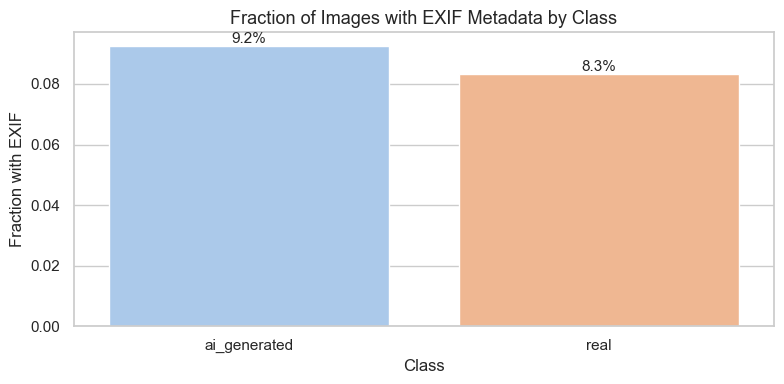

In [22]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(
    data=labeled_profile_df,
    x='label_name',
    y='has_exif',
    hue='label_name',
    estimator=np.mean,
    errorbar=None,
    palette='pastel',
    legend=False,
)
ax.set_title('Fraction of Images with EXIF Metadata by Class', fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Fraction with EXIF')
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1%}',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', va='bottom', fontsize=11,
    )
plt.tight_layout()
plt.show()


## 13. Data Quality Checks

We now check for common dataset issues:

- missing labels
- missing files
- corrupted images
- duplicate files by content hash


In [23]:
quality_report = {
    'missing_train_labels':      int(metadata_df.loc[metadata_df['split'] == 'train', 'ground_truth'].isna().sum()),
    'missing_referenced_files':  int((~metadata_df['file_exists']).sum()),
    'corrupted_images':          int(profile_df['is_corrupted'].sum()),
    'duplicate_images_by_md5':   int(profile_df['is_duplicate'].sum()),
}
quality_report_df = pd.DataFrame({
    'metric': quality_report.keys(),
    'count':  quality_report.values(),
    'status': ['OK' if v == 0 else 'WARN' for v in quality_report.values()],
})
print('Data quality report:')
display(quality_report_df)

total_issues = sum(quality_report.values())
print(f'\nTotal data quality issues: {total_issues}')
if total_issues == 0:
    print('  All checks passed — dataset is clean.')
else:
    for k, v in quality_report.items():
        if v > 0:
            print(f'  [WARN] {k}: {v}')


Data quality report:


,metric,count,status
0,missing_train_labels,0,OK
1,missing_referenced_files,0,OK
2,corrupted_images,0,OK
3,duplicate_images_by_md5,0,OK



Total data quality issues: 0
  All checks passed — dataset is clean.


In [24]:
duplicate_preview = profile_df.loc[
    profile_df['is_duplicate'], ['file_name', 'md5', 'label_name', 'split']
].sort_values('md5')

if duplicate_preview.empty:
    print('No duplicate images detected by MD5 hash.')
    print('Each image has a unique content fingerprint — no cross-contamination.')
else:
    print(f'{len(duplicate_preview)} duplicate image entries detected (same file content, possibly different names).')
    display(duplicate_preview.head(20))
    dup_groups      = profile_df.loc[profile_df['is_duplicate']].groupby('md5')['label_name'].nunique()
    cross_class_cnt = int((dup_groups > 1).sum())
    if cross_class_cnt > 0:
        print(f'\n  [WARN] {cross_class_cnt} MD5 group(s) span multiple classes — potential label leakage!')
    else:
        print('\n  Duplicates are within the same class only — no cross-class contamination.')


No duplicate images detected by MD5 hash.
Each image has a unique content fingerprint — no cross-contamination.


## 14. Corrupted or Anomalous Image Inspection

We flag unusually smooth or unusually high-frequency images using rough percentile-based thresholds. These can be worth inspecting manually because they may correspond to synthetic artifacts, compression issues, or broken inputs.


In [25]:
smooth_threshold = labeled_profile_df['laplacian_var'].quantile(0.05)
noisy_threshold  = labeled_profile_df['fft_high_freq_ratio'].quantile(0.95)

smooth_examples  = labeled_profile_df.nsmallest(4, 'laplacian_var')
noisy_examples   = labeled_profile_df.nlargest(4,  'fft_high_freq_ratio')

n_smooth = int((labeled_profile_df['laplacian_var']       <= smooth_threshold).sum())
n_noisy  = int((labeled_profile_df['fft_high_freq_ratio'] >= noisy_threshold).sum())

threshold_df = pd.DataFrame({
    'threshold_name':  ['smooth (p5 Laplacian var)', 'high-freq (p95 FFT ratio)'],
    'threshold_value': [smooth_threshold, noisy_threshold],
    'images_flagged':  [n_smooth, n_noisy],
})
print('Anomaly thresholds and flagged counts:')
display(threshold_df.round(4))

print(f'\nSmooth images (bottom 5% Laplacian var) : {n_smooth}')
smooth_class = labeled_profile_df.loc[labeled_profile_df['laplacian_var'] <= smooth_threshold, 'label_name'].value_counts()
display(smooth_class.to_frame('count').rename_axis('label'))

print(f'\nHigh-freq images (top 5% FFT ratio)     : {n_noisy}')
noisy_class = labeled_profile_df.loc[labeled_profile_df['fft_high_freq_ratio'] >= noisy_threshold, 'label_name'].value_counts()
display(noisy_class.to_frame('count').rename_axis('label'))


Anomaly thresholds and flagged counts:


,threshold_name,threshold_value,images_flagged
0,smooth (p5 Laplacian var),NaN,0
1,high-freq (p95 FFT ratio),0.7837,240



Smooth images (bottom 5% Laplacian var) : 0


,count
label,



High-freq images (top 5% FFT ratio)     : 240


,count
label,
real,128
ai_generated,112


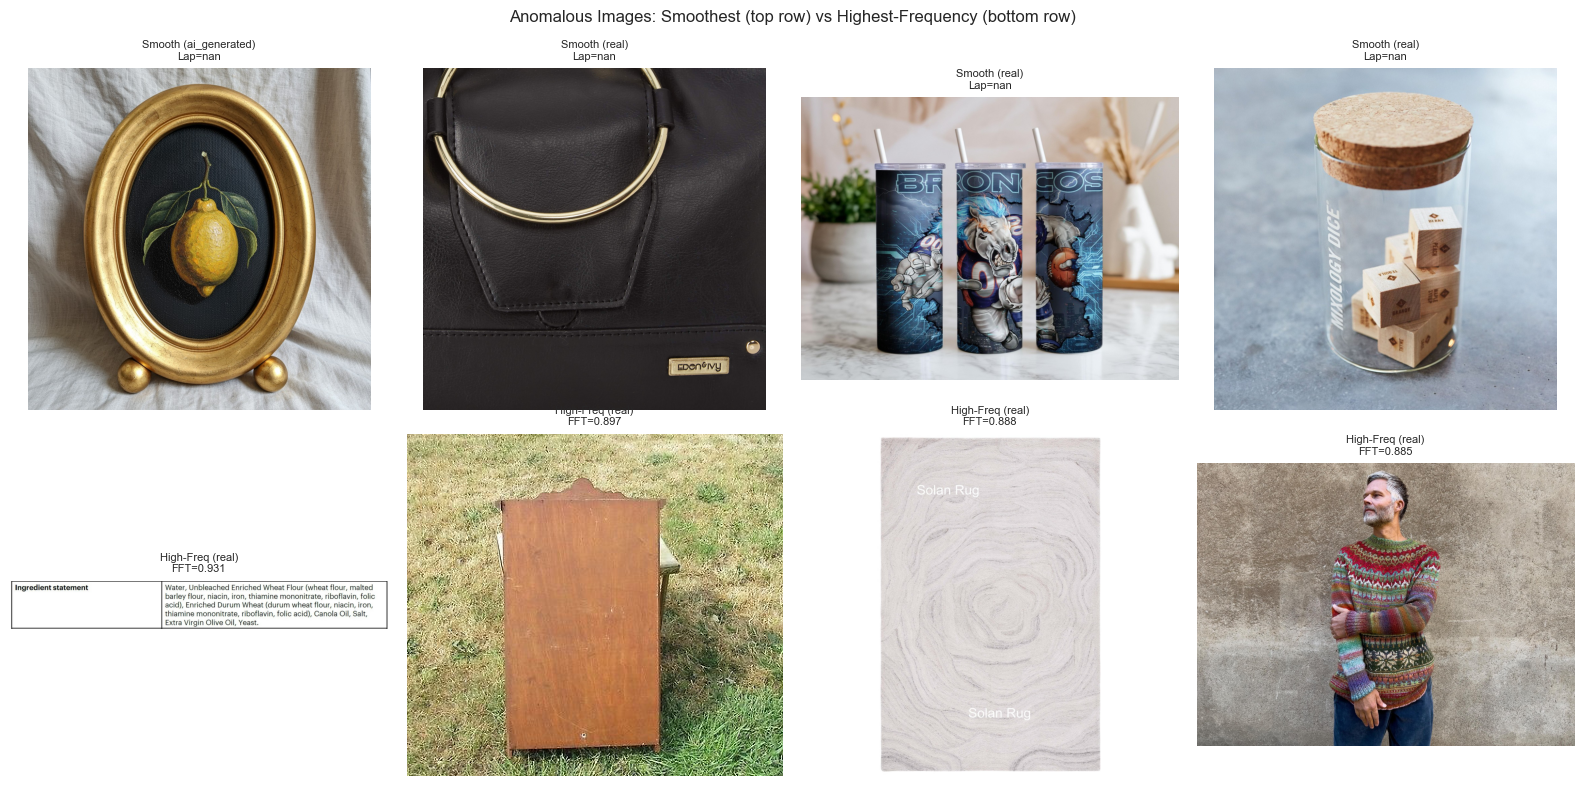

In [26]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes[0], smooth_examples.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'Smooth ({row["label_name"]})'
                 f'\nLap={row["laplacian_var"]:.1f}', fontsize=8)
    ax.axis('off')
for ax, (_, row) in zip(axes[1], noisy_examples.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(f'High-Freq ({row["label_name"]})'
                 f'\nFFT={row["fft_high_freq_ratio"]:.3f}', fontsize=8)
    ax.axis('off')
fig.suptitle('Anomalous Images: Smoothest (top row) vs Highest-Frequency (bottom row)', fontsize=12)
plt.tight_layout()
plt.show()


## 15. Example Comparisons: Real vs AI-Generated

This final visual comparison pairs examples from each class to make the statistical differences more concrete.


Feature comparison for sampled images (mean over 3 per class):


,file_size_kb,laplacian_var,fft_high_freq_ratio,pixel_std
label_name,,,,
ai_generated,280.163,NaN,0.700,61.543999
real,121.898,NaN,0.625,63.875999


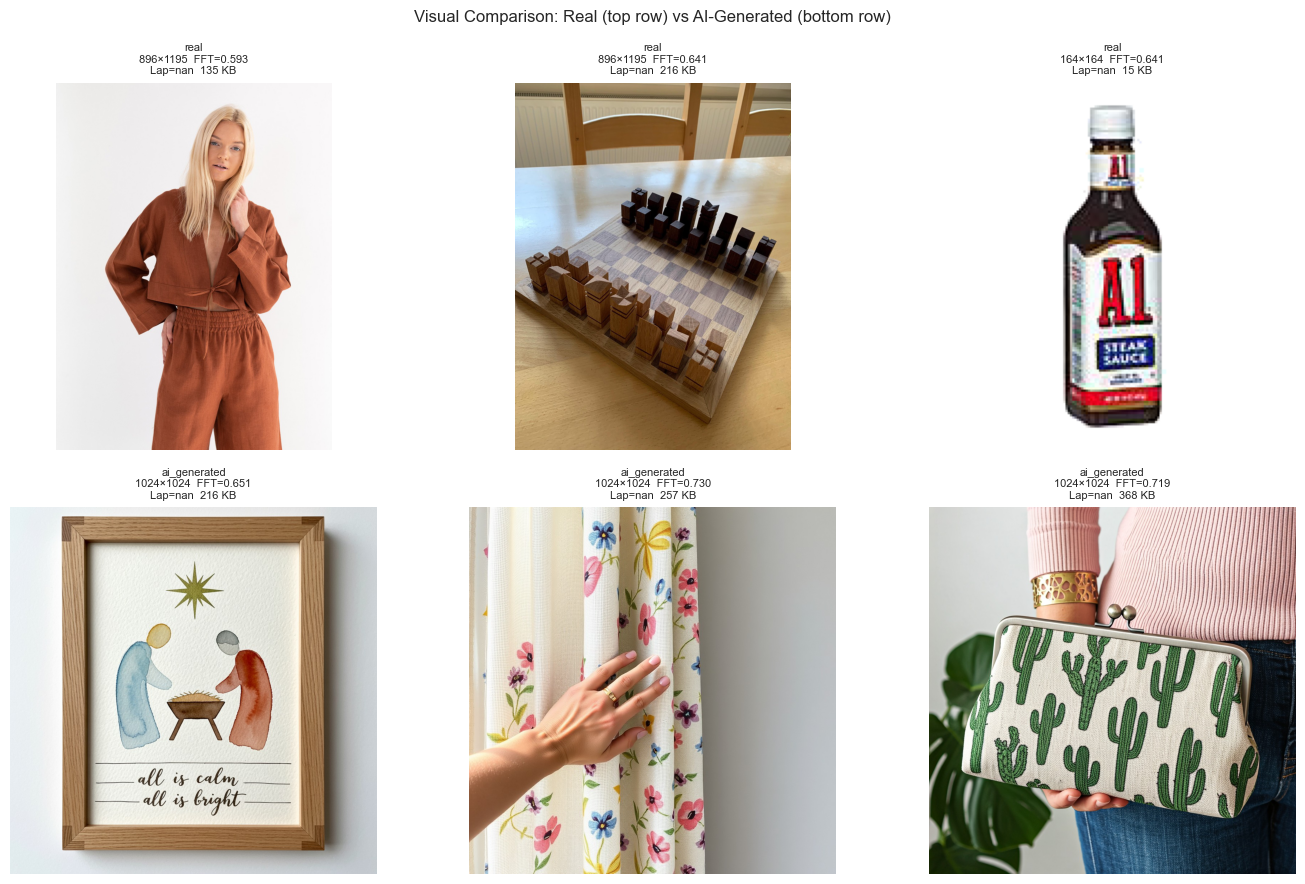

In [27]:
comparison_real = labeled_profile_df.loc[labeled_profile_df['ground_truth'] == 0].sample(3, random_state=7)
comparison_ai   = labeled_profile_df.loc[labeled_profile_df['ground_truth'] == 1].sample(3, random_state=7)
comparison_df   = pd.concat(
    [comparison_real.assign(column='real'), comparison_ai.assign(column='ai_generated')],
    ignore_index=True,
)

key_features = ['file_size_kb', 'laplacian_var', 'fft_high_freq_ratio', 'pixel_std']
print('Feature comparison for sampled images (mean over 3 per class):')
display(comparison_df.groupby('label_name')[key_features].mean().round(3))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (_, row) in zip(axes.flatten(), comparison_df.iterrows()):
    img = Image.open(row['image_path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(
        row['label_name']
        + f'\n{int(row["width"])}×{int(row["height"])}  FFT={row["fft_high_freq_ratio"]:.3f}'
        + f'\nLap={row["laplacian_var"]:.1f}  {row["file_size_kb"]:.0f} KB',
        fontsize=8,
    )
    ax.axis('off')
fig.suptitle('Visual Comparison: Real (top row) vs AI-Generated (bottom row)', fontsize=12)
plt.tight_layout()
plt.show()


## 16. Feature Insights for AI Detection

Based on the profiling above, the most useful candidate signals for AI-vs-real detection are likely to be:

- **Texture inconsistency**: unusually low or unusually high edge / detail patterns
- **Color distribution shifts**: differences in RGB means or channel variance
- **Frequency artifacts**: abnormal FFT high-frequency ratios
- **Compression / file-size signatures**: generation pipelines often leave different file-size footprints
- **Metadata absence**: EXIF may help separate camera-origin images from generated or heavily processed ones
- **Duplicate content or near-duplicates**: useful for leakage checks and train/validation hygiene

These insights can guide downstream feature engineering and model design.


Candidate feature signals — mean values by class:


label_name,ai_generated,real
file_size_kb,186.0209,208.8797
aspect_ratio,1.0855,1.0219
rgb_mean_r,165.7853,170.0401
rgb_mean_g,155.6486,159.6515
rgb_mean_b,145.5925,151.5409
laplacian_var,NaN,NaN
pixel_std,55.1293,55.8800
fft_high_freq_ratio,0.6409,0.6328
has_exif,0.0924,0.0833



Largest mean differences between classes:


,real_mean,ai_generated_mean,absolute_diff,direction
file_size_kb,208.8797,186.0209,22.8588,Real > AI
rgb_mean_b,151.5409,145.5925,5.9484,Real > AI
rgb_mean_r,170.0401,165.7853,4.2548,Real > AI
rgb_mean_g,159.6515,155.6486,4.0029,Real > AI
pixel_std,55.8800,55.1293,0.7507,Real > AI
aspect_ratio,1.0219,1.0855,0.0636,AI > Real
has_exif,0.0833,0.0924,0.0091,AI > Real
fft_high_freq_ratio,0.6328,0.6409,0.0082,AI > Real
laplacian_var,NaN,NaN,NaN,AI > Real


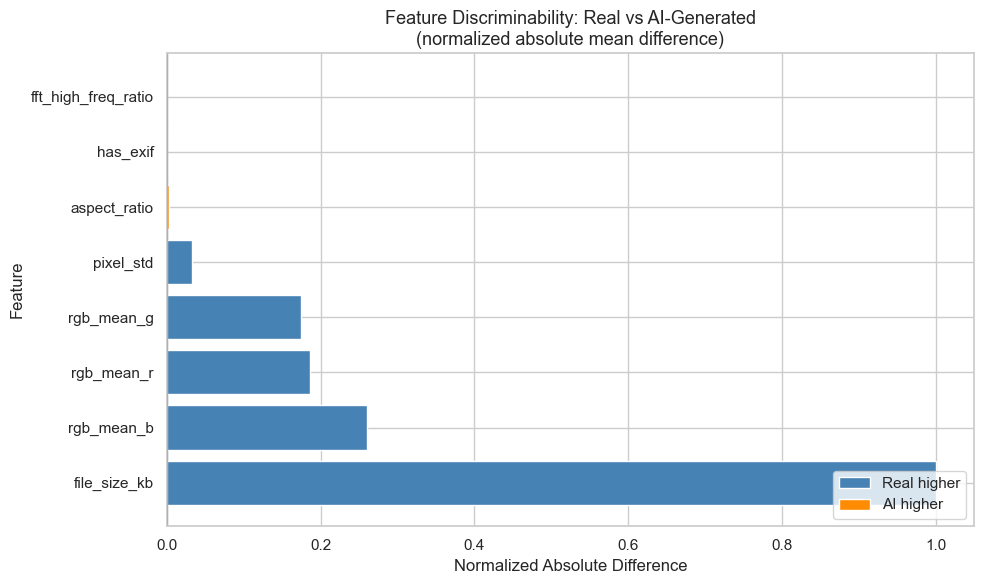


FFT Magnitude Spectra — sample real vs AI-generated images:


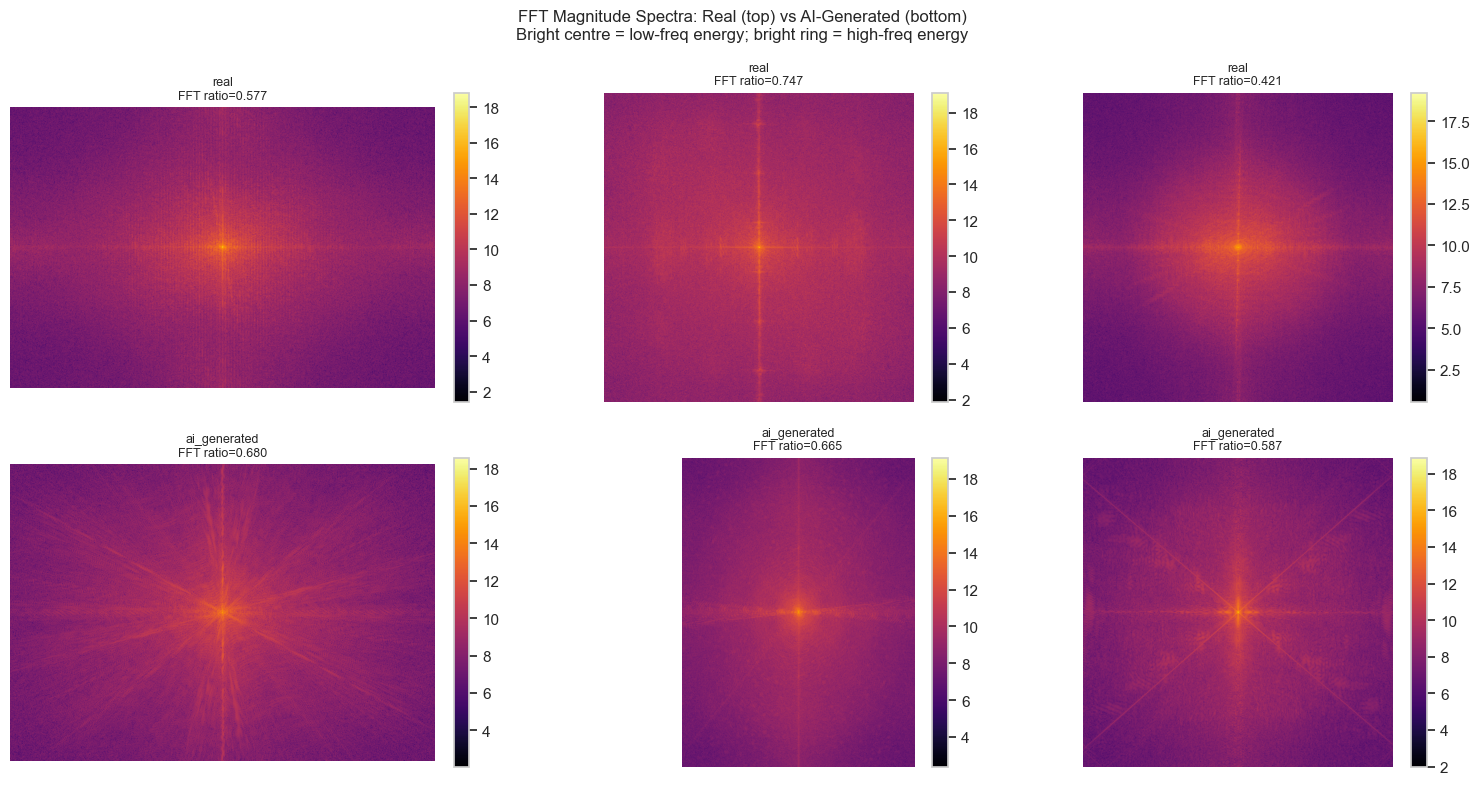

In [28]:
insight_table = (
    labeled_profile_df.groupby('label_name')[
        ['file_size_kb', 'aspect_ratio', 'rgb_mean_r', 'rgb_mean_g', 'rgb_mean_b',
         'laplacian_var', 'pixel_std', 'fft_high_freq_ratio', 'has_exif']
    ]
    .mean()
    .T
)
print('Candidate feature signals — mean values by class:')
display(insight_table.round(4))

insight_delta = pd.DataFrame({
    'real_mean':         insight_table['real'],
    'ai_generated_mean': insight_table['ai_generated'],
    'absolute_diff':     (insight_table['real'] - insight_table['ai_generated']).abs(),
    'direction':         ['Real > AI' if r > a else 'AI > Real'
                          for r, a in zip(insight_table['real'], insight_table['ai_generated'])],
}).sort_values('absolute_diff', ascending=False)
print('\nLargest mean differences between classes:')
display(insight_delta.round(4))

# ── Bar chart of normalised feature deltas ───────────────────────────────────
max_diff = insight_delta['absolute_diff'].max()
insight_delta['norm_diff'] = insight_delta['absolute_diff'] / max_diff

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['steelblue' if d == 'Real > AI' else 'darkorange' for d in insight_delta['direction']]
ax.barh(insight_delta.index, insight_delta['norm_diff'], color=colors)
ax.set_title('Feature Discriminability: Real vs AI-Generated\n(normalized absolute mean difference)', fontsize=13)
ax.set_xlabel('Normalized Absolute Difference')
ax.set_ylabel('Feature')
ax.axvline(0, color='black', linewidth=0.8)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='steelblue', label='Real higher'),
                   Patch(facecolor='darkorange', label='AI higher')],
          loc='lower right')
plt.tight_layout()
plt.show()

# ── FFT Spectrum Visualization ───────────────────────────────────────────────
print('\nFFT Magnitude Spectra — sample real vs AI-generated images:')
fft_real = labeled_profile_df.loc[labeled_profile_df['ground_truth'] == 0].sample(3, random_state=99)
fft_ai   = labeled_profile_df.loc[labeled_profile_df['ground_truth'] == 1].sample(3, random_state=99)
fft_rows = pd.concat([fft_real, fft_ai], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (_, row) in zip(axes.flatten(), fft_rows.iterrows()):
    with Image.open(row['image_path']) as img:
        gray = np.asarray(img.convert('L'), dtype=np.float32)
    magnitude = np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(gray))))
    im = ax.imshow(magnitude, cmap='inferno')
    ax.set_title(f'{row["label_name"]}\nFFT ratio={row["fft_high_freq_ratio"]:.3f}', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(
    'FFT Magnitude Spectra: Real (top) vs AI-Generated (bottom)\n'
    'Bright centre = low-freq energy; bright ring = high-freq energy',
    fontsize=12,
)
plt.tight_layout()
plt.show()


## 17. Summary

This notebook produced:

- dataset availability and class distribution checks
- sample image inspection
- descriptive statistics for image size and file size
- RGB and pixel-intensity analysis
- texture / smoothness / FFT-based artifact analysis
- EXIF metadata profiling
- data quality checks for missing files, corruption, and duplicates
- candidate feature insights for distinguishing AI-generated vs real images

This is a strong profiling foundation for the next stage: building robust AI-image detection features and models.
